In [1]:
import numpy as np
import networkx as nx
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

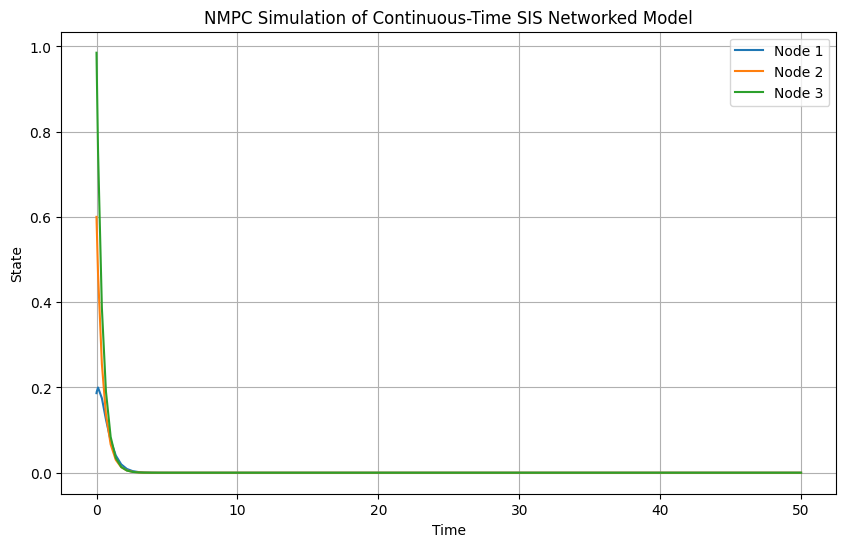

In [ ]:
def continuous_dynamics(t, x_vec, A, B, D):
    #this is just the continuous time SIS networked model dynamics
    dx_dt = -D @ x_vec[:-1] + (np.eye(A.shape[0]) - np.diag(x_vec[:-1])) @ B @ A @ x_vec[:-1]
    #also have a dummy variable forthe cost function, since we are minimizing
    # - sum_{i = 1}^N \integral x_i(t) over the time horizon
    di_dt = np.sum(x_vec[:-1])
    return np.concatenate((dx_dt, [di_dt]))

#This function should simulate the continuous dynamics over a time horizon
#returns the cost we want to minimize
def simulate_horizon(update_list, H, x_vec_0, A, B, D, tau_k):
    #initialize the simulation variables
    current_x_vec = x_vec_0
    current_B = B
    current_D = D
    current_integral= 0
    current_t = tau_k

    final_time = tau_k + H
    start_time = tau_k
    #do this because the optimizer can choose update times that are not in the right order
    update_list = np.sort(update_list)
    #add these to the update list to make it easier to handle the intervals (if they arent already there)
    if start_time not in update_list:
        update_list = np.concatenate(([start_time], update_list))
    if final_time not in update_list:
        update_list = np.append(update_list, final_time)
    #simulate the dynamics over the time horizon
    m = len(update_list) # not really m all the time since technically we added start and end time
    for i in range(m - 1):
        t_start = update_list[i]
        t_end = update_list[i + 1]
        #make sure each interval has a positive length
        if t_end == t_start:
            continue
        #now simulate the dynamics: 
        sol = solve_ivp(continuous_dynamics,
                                [t_start, t_end], 
                                np.concatenate((current_x_vec, [current_integral])), 
                                args=(A, current_B, current_D), 
                                dense_output=False
                                #Im just setting this to false for now since it returns an array hich is easier to handlke
                )
        current_x_vec = sol.y[:-1, -1] #get the last state from this time interval
        current_integral = sol.y[-1, -1] #get the last integral value from this time interval

    return current_integral, current_x_vec, sol.y, sol.t

#given a start time do NMPC over the time horizon
def interval_NMPC(x_vec, A, B, D, H, m, tau_k):
    def objective(u):
        #simulate the dynamics over the time horizon
        cost, _, _, _ = simulate_horizon(u, H, x_vec, A, B, D, tau_k)
        return -1 * cost #because we minimizing
    update_list_guess = np.linspace(tau_k, tau_k + H, m+2)
    update_list_guess = update_list_guess[1:-1] #remove the first and last elements since they are fixed
    bounds = [(tau_k, tau_k + H) for _ in range(m)]
    result = minimize(
        objective,
        update_list_guess,
        bounds=bounds,
        method='SLSQP',
        options={'disp': False} #dont need the messages and stuff, letit do its thing
    )
    return result



def NMPC_simulation(x_vec_0, A, B, D, H, m, total_time):
    #initialize the sim variables
    current_x_vec = x_vec_0
    current_t = 0
    x_vec_history = []
    t_history = []

    current_B = B
    current_D = D
    #run the NMPC simulation
    while current_t < total_time:
        #run the NMPC optimization to get the optimal update times
        result = interval_NMPC(current_x_vec, A, B, D, H, m, current_t)
        optimal_update_times = result.x
        optimal_update_times = np.sort(result.x) #sort to keep the order of update times
        future_updates = optimal_update_times[optimal_update_times > current_t + 1e-5]
        
        if len(future_updates) > 0:
            next_update_time = future_updates[0]
        else:
            # Fallback: If no future updates are found in the horizon, step forward by H
            next_update_time = current_t + H 
            
        # Ensure we don't simulate past the total_time limit
        next_update_time = min(next_update_time, total_time)
        
        #simulate just to the next update time
        #now simulate the dynamics ONLY to the next update time
        solve_ivp_result = solve_ivp(continuous_dynamics,
                                     [current_t, next_update_time],
                                     np.concatenate((current_x_vec, [0])), #the last element is the integral, but we dont care about it here
                                     args=(A, B, D), 
                                        dense_output=False
                                        )
       
        #Get the histories for plotting
        interval_state_history = solve_ivp_result.y[:-1, :] #get the state history from this time interval
        interval_time_history = solve_ivp_result.t #get the time history from this time interval
        #append the state and time history to the overall history
        x_vec_history.append(interval_state_history.T) #transpose to get the right shape
        t_history.append(interval_time_history)

        #update variables for the next iteration
        current_t = next_update_time
        current_x_vec = solve_ivp_result.y[:-1, -1] #get the last state from this time interval

        #APPLY THE DISCRETE JUMPS HERE

    return np.concatenate(x_vec_history, axis=0), np.concatenate(t_history, axis=0) #return the state and time histories

#sim parameters
H  = 10
#network parameters
#make the adjacency matrix for the network ER graph
n = 3
p = 0.5
Graph = nx.erdos_renyi_graph(n, p, seed=42)
x_vec_0 = np.random.uniform(0, 1, n) 
D = np.diag(np.random.uniform(2, 3, n))
B = np.diag(np.random.uniform(0, 1, n))
state_history, time_history = NMPC_simulation(x_vec_0, nx.to_numpy_array(Graph), B, D, H, m=2, total_time=50)
#plot the results
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(time_history, state_history[:, i], label=f'Node {i+1}')
plt.xlabel('Time')
plt.ylabel('State')
plt.title('NMPC Simulation of Continuous-Time SIS Networked Model')
plt.legend()
plt.grid()
plt.show()
